# Adjoint Solver for Spring-Slider Rate-and-State Friction

Extends the existing `springslider.ipynb` forward solver with an adjoint-based gradient computation.

**Setup:** Velocity-strengthening friction (`a > b`), afterslip problem, fixed-step RK4.

**State evolution:** Slip law — matches the existing forward solver exactly.

**Force balance convention:**
$$\tau(V,\psi) + \eta V + k u = \tau_0$$

**Adjoint system (backward in time, $p=u^\dagger$, $r=\psi^\dagger$, $p(T)=r(T)=0$):**
$$\dot{V}^\dagger = k\,\frac{p - (V - V_{\rm obs}) + G_V\, r}{\tau_V + \eta}, \quad
\dot{p} = \dot{V}^\dagger, \quad
\dot{r} = \frac{\tau_\psi}{k}\dot{V}^\dagger - G_\psi\, r$$

**Gradient:**
$$\frac{dJ}{da} = \int_0^T \left[\frac{\dot{V}^\dagger}{k}\,\frac{\partial\tau}{\partial a} - r\,\frac{\partial G}{\partial a}\right]dt$$

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

## Physics: Friction Law and Jacobians

**Regularised RS friction (slip-law form used in original code):**
$$\tau(V,\psi) = N a\,\sinh^{-1}\!\left(\frac{V}{2V_0}e^{\psi/a}\right)$$

**State evolution — slip law:**
$$G(V,\psi) = -\frac{V}{D_c}\left(\frac{\tau}{N} - f_{\rm ss}\right), \quad f_{\rm ss} = f_0 + (a-b)\ln(V/V_0)$$

Partial derivatives are derived analytically.

In [140]:
# ------------------------------------------------------------------
# Friction law
# ------------------------------------------------------------------

def xi_fn(V, psi, M):
    """Argument of arcsinh: xi = V/(2*V0) * exp(psi/a)."""
    return V / (2.0 * M['V0']) * np.exp(psi / M['a'])

def tau_fn(V, psi, M):
    """Frictional strength (MPa)."""
    return M['N'] * M['a'] * np.arcsinh(xi_fn(V, psi, M))

def fss_fn(V, M):
    """Steady-state friction coefficient."""
    return M['f0'] + (M['a'] - M['b']) * np.log(V / M['V0'])

def G_fn(V, psi, M):
    """State evolution dpsi/dt (slip law)."""
    f = tau_fn(V, psi, M) / M['N']
    return -V / M['dc'] * (f - fss_fn(V, M))

# ------------------------------------------------------------------
# Partial derivatives
# ------------------------------------------------------------------

def tau_V_fn(V, psi, M):
    """dtau/dV = N*a / sqrt(1+xi^2) * xi/V."""
    xi = xi_fn(V, psi, M)
    return M['N'] * M['a'] / np.sqrt(1.0 + xi**2) * xi / V

def tau_psi_fn(V, psi, M):
    """dtau/dpsi = N * xi / sqrt(1+xi^2)."""
    xi = xi_fn(V, psi, M)
    return M['N'] * xi / np.sqrt(1.0 + xi**2)

def G_V_fn(V, psi, M):
    """
    dG/dV for slip law.
    G = -(V/dc)*(tau/N - fss), so
    dG/dV = G/V - V*tau_V/(dc*N) + (a-b)/dc
    """
    G  = G_fn(V, psi, M)
    tV = tau_V_fn(V, psi, M)
    return G / V - V * tV / (M['dc'] * M['N']) + (M['a'] - M['b']) / M['dc']

def G_psi_fn(V, psi, M):
    """dG/dpsi = -V * tau_psi / (dc * N)."""
    tP = tau_psi_fn(V, psi, M)
    return -V * tP / (M['dc'] * M['N'])

def dtau_da_fn(V, psi, M):
    """
    Explicit partial dtau/da  (holding V, psi fixed).
    tau = N*a*arcsinh(xi),  xi = V/(2*V0)*exp(psi/a)
    d(tau)/da = N*arcsinh(xi) - N*psi*xi / (a*sqrt(1+xi^2))
    """
    xi = xi_fn(V, psi, M)
    return M['N'] * np.arcsinh(xi) - M['N'] * psi * xi / (M['a'] * np.sqrt(1.0 + xi**2))

def dG_da_fn(V, psi, M):
    """
    Explicit partial dG/da  (holding V, psi fixed).
    G = -(V/dc)*(tau/N - fss),  dfss/da = ln(V/V0)
    dG/da = -(V/dc)*(dtau_da/N - ln(V/V0))
    """
    dtau = dtau_da_fn(V, psi, M)
    return -(V / M['dc']) * (dtau / M['N'] - np.log(V / M['V0']))

print("Physics functions defined.")

Physics functions defined.


## Parameters and Afterslip Initial Conditions

Velocity-strengthening (`a > b`) with a coseismic stress step $\Delta\tau$ at $t=0$.

In [184]:
# ------------------------------------------------------------------
# Force-balance solver:  tau(V,psi) + eta*V + k*u = tau_L  =>  V
# ------------------------------------------------------------------

def solve_V_algebraic(u, psi, M, tau_L):
    """
    Root-find V from  tau(V,psi) + eta*V = tau_L - k*u.
    tau_L is the current loading stress (may vary with time).
    """
    rhs = tau_L - M['k'] * u
    if rhs <= 0.0:
        raise ValueError(f"Force-balance RHS = {rhs:.4g} <= 0; check tau_L and k*u.")
    def res(V):
        return tau_fn(V, psi, M) + M['eta'] * V - rhs
    Vmin = 1e-30
    Vmax = rhs / M['eta']
    return brentq(res, Vmin, Vmax, xtol=1e-20, rtol=1e-10)

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
M = {}
M['f0']  = 0.6       # reference friction coefficient
M['V0']  = 1e-6      # m/s reference velocity
M['a']   = 0.010     # direct effect (a > b → velocity strengthening)
M['b']   = 0.015     # state evolution
M['dc']  = 1e-4      # m, critical slip distance
M['N']   = 50.0      # MPa effective normal stress
M['eta'] = 2.7 * 3.5 / 2.0   # MPa·s/m radiation damping
k_crit = (M['N'] * (M['b'] - M['a']))/M['dc'] # WHERE IS THIS FROM?
M['k']   = 0.9*k_crit   # MPa/m spring stiffness

V_bg      = 1e-9     # m/s background / plate sliding rate
M['V_bg'] = V_bg     # store in M so forward_solve can access it

Delta_tau = 0.0      # MPa coseismic stress step (set to 0 for pure loading)

# ------------------------------------------------------------------
# Steady-state at V_bg (slip law):  tau(V_bg, psi_ss)/N = fss(V_bg)
#   => psi_ss = a * ln(2*V0/V_bg * sinh(fss_bg/a))
# ------------------------------------------------------------------
fss_bg = fss_fn(V_bg, M)
psi_ss = M['a'] * np.log(2.0 * M['V0'] / V_bg * np.sinh(fss_bg / M['a']))
tau_ss = M['N'] * fss_bg

M['tau0'] = tau_ss + Delta_tau   # loading stress at t=0


# Initial conditions (at steady state before coseismic step)
u_init   = 0.0
psi_init = psi_ss
V_init   = 1e-18 #solve_V_algebraic(u_init, psi_init, M, M['tau0'])

# Characteristic afterslip decay time  T_c ~ N*a / (k * V_init)
T_c = M['N'] * M['a'] / (M['k'] * V_init)

print(f"Velocity-strengthening:  a={M['a']}, b={M['b']}  (a > b = {M['a'] > M['b']})")
print(f"V_bg   = {V_bg:.2e} m/s")
print(f"psi_ss = {psi_ss:.4f}")
print(f"tau_ss = {tau_ss:.4f} MPa,  tau0 = {M['tau0']:.4f} MPa")
print(f"V_init = {V_init:.4e} m/s  (V_init/V_bg = {V_init/V_bg:.1f})")
print(f"T_c    = {T_c:.3e} s  ({T_c/86400:.1f} days)")
print(f"Tectonic stressing rate = {M['k']*V_bg*1e3*3.15e7:.3f} MPa/yr")
print(f"k_crit   = {k_crit:.2e} MPa/m")

Velocity-strengthening:  a=0.01, b=0.015  (a > b = False)
V_bg   = 1.00e-09 m/s
psi_ss = 0.7036
tau_ss = 31.7269 MPa,  tau0 = 31.7269 MPa
V_init = 1.0000e-18 m/s  (V_init/V_bg = 0.0)
T_c    = 2.222e+14 s  (2572016460.9 days)
Tectonic stressing rate = 70875.000 MPa/yr
k_crit   = 2.50e+03 MPa/m


## Fixed-Step RK4 Forward Solver

Stores full history of `V`, `psi`, `u` and all Jacobians needed for the adjoint.

In [185]:
def forward_solve(M, T, nt, u0, psi0):
    """
    Fixed-step RK4 forward solve with linear tectonic loading.

    Loading stress:  tau_L(t) = tau0 + k * V_bg * t
    Force balance:   tau(V,psi) + eta*V + k*u = tau_L(t)  =>  V  (algebraic)
    State ODEs:      du/dt = V,   dpsi/dt = G(V,psi)

    Returns dict with full time history + Jacobian arrays.
    """
    dt = T / nt
    t  = np.linspace(0.0, T, nt + 1)

    # Pre-compute loading stress at every node and at half-nodes for RK4
    tau_L     = M['tau0'] + M['k'] * M['V_bg'] * t          # shape (nt+1,)
    tau_L_mid = M['tau0'] + M['k'] * M['V_bg'] * (t[:-1] + 0.5*dt)  # at n+1/2

    u   = np.zeros(nt + 1)
    psi = np.zeros(nt + 1)
    V_arr       = np.zeros(nt + 1)
    tau_V_arr   = np.zeros(nt + 1)
    tau_P_arr   = np.zeros(nt + 1)
    G_V_arr     = np.zeros(nt + 1)
    G_P_arr     = np.zeros(nt + 1)
    dtau_da_arr = np.zeros(nt + 1)
    dG_da_arr   = np.zeros(nt + 1)

    u[0], psi[0] = u0, psi0

    def _store(n, Vn, pn):
        V_arr[n]       = Vn
        tau_V_arr[n]   = tau_V_fn(Vn, pn, M)
        tau_P_arr[n]   = tau_psi_fn(Vn, pn, M)
        G_V_arr[n]     = G_V_fn(Vn, pn, M)
        G_P_arr[n]     = G_psi_fn(Vn, pn, M)
        dtau_da_arr[n] = dtau_da_fn(Vn, pn, M)
        dG_da_arr[n]   = dG_da_fn(Vn, pn, M)

    _store(0, solve_V_algebraic(u0, psi0, M, tau_L[0]), psi0)

    for n in range(nt):
        tL_n   = tau_L[n]       # loading stress at t_n
        tL_mid = tau_L_mid[n]   # loading stress at t_{n+1/2}
        tL_np1 = tau_L[n+1]     # loading stress at t_{n+1}

        V1 = solve_V_algebraic(u[n], psi[n], M, tL_n)
        G1 = G_fn(V1, psi[n], M)

        u2 = u[n] + 0.5*dt*V1;  p2 = psi[n] + 0.5*dt*G1
        V2 = solve_V_algebraic(u2, p2, M, tL_mid)
        G2 = G_fn(V2, p2, M)

        u3 = u[n] + 0.5*dt*V2;  p3 = psi[n] + 0.5*dt*G2
        V3 = solve_V_algebraic(u3, p3, M, tL_mid)
        G3 = G_fn(V3, p3, M)

        u4 = u[n] + dt*V3;      p4 = psi[n] + dt*G3
        V4 = solve_V_algebraic(u4, p4, M, tL_np1)
        G4 = G_fn(V4, p4, M)

        u[n+1]   = u[n]   + dt/6*(V1 + 2*V2 + 2*V3 + V4)
        psi[n+1] = psi[n] + dt/6*(G1 + 2*G2 + 2*G3 + G4)

        _store(n+1, solve_V_algebraic(u[n+1], psi[n+1], M, tL_np1), psi[n+1])

    return dict(
        t=t, u=u, psi=psi,
        V=V_arr, tau_L=tau_L,
        tau_V=tau_V_arr, tau_psi=tau_P_arr,
        G_V=G_V_arr,   G_psi=G_P_arr,
        dtau_da=dtau_da_arr, dG_da=dG_da_arr,
        dt=dt, nt=nt
    )

# ------------------------------------------------------------------
# Run forward solve
# ------------------------------------------------------------------
T   = 5e6    # s
nt  = 6000   # fixed time steps

print(f"Running forward solve: T={T:.1e} s, nt={nt}, dt={T/nt:.0f} s ...")
fwd = forward_solve(M, T, nt, u_init, psi_init)
print(f"Done. V(0) = {fwd['V'][0]:.3e}, V(T) = {fwd['V'][-1]:.3e} m/s")
print(f"tau_L(0) = {fwd['tau_L'][0]:.4f} MPa  →  tau_L(T) = {fwd['tau_L'][-1]:.4f} MPa")

Running forward solve: T=5.0e+06 s, nt=6000, dt=833 s ...
Done. V(0) = 1.000e-09, V(T) = 1.000e-09 m/s
tau_L(0) = 31.7269 MPa  →  tau_L(T) = 42.9769 MPa


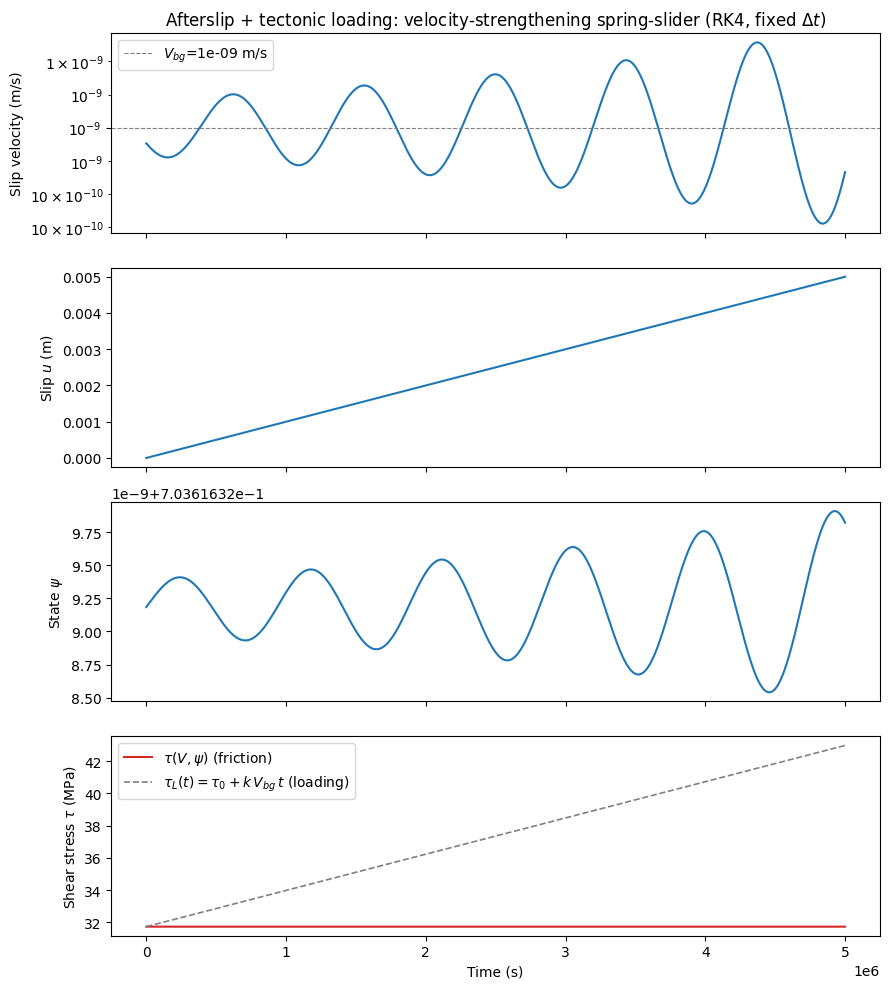

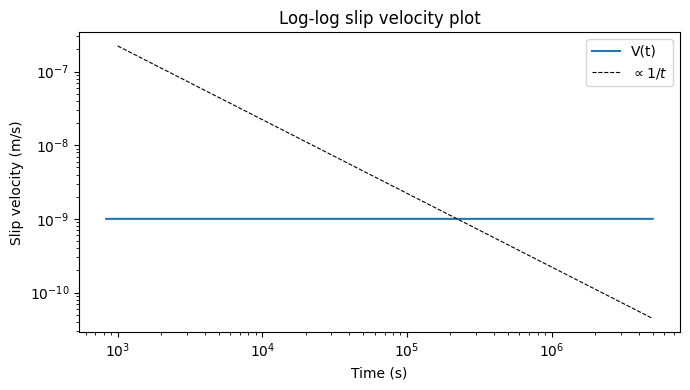

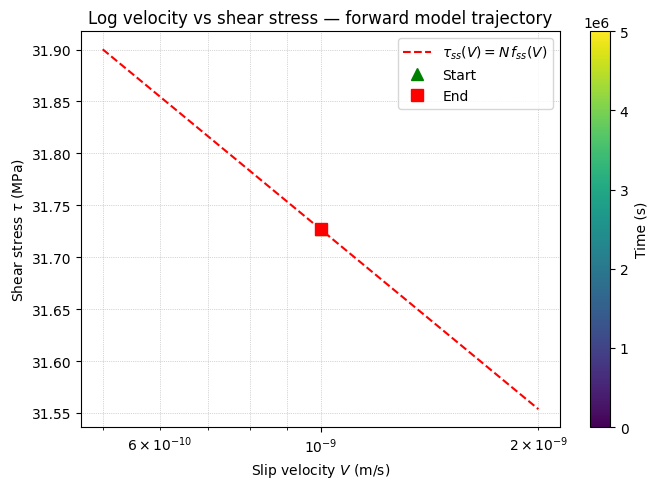

tau range: 31.7269 – 31.7269 MPa
V   range: 1.000e-09 – 1.000e-09 m/s


In [186]:
# ------------------------------------------------------------------
# Plot 1: Forward solution
# ------------------------------------------------------------------
tau_fwd = np.array([tau_fn(v, p, M) for v, p in zip(fwd['V'], fwd['psi'])])

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].semilogy(fwd['t'], fwd['V'])
axes[0].axhline(V_bg, color='gray', ls='--', lw=0.8, label=f'$V_{{bg}}$={V_bg:.0e} m/s')
axes[0].set_ylabel('Slip velocity (m/s)')
axes[0].set_title('Afterslip + tectonic loading: velocity-strengthening spring-slider (RK4, fixed $\\Delta t$)')
axes[0].legend()

axes[1].plot(fwd['t'], fwd['u'])
axes[1].set_ylabel('Slip $u$ (m)')

axes[2].plot(fwd['t'], fwd['psi'])
axes[2].set_ylabel('State $\\psi$')

axes[3].plot(fwd['t'], tau_fwd, color='C3', label=r'$\tau(V,\psi)$ (friction)')
axes[3].plot(fwd['t'], fwd['tau_L'], color='gray', ls='--', lw=1.2,
             label=r'$\tau_L(t) = \tau_0 + k\,V_{bg}\,t$ (loading)')
axes[3].set_ylabel('Shear stress $\\tau$ (MPa)')
axes[3].set_xlabel('Time (s)')
axes[3].legend()

plt.tight_layout()
plt.show()

# Verify Omori-like 1/t decay by log-log plot
fig2, ax2 = plt.subplots(figsize=(7, 4))
t_plot = fwd['t'][1:]
V_plot = fwd['V'][1:]
ax2.loglog(t_plot, V_plot, label='V(t)')
t_ref = np.array([1e3, T])
ax2.loglog(t_ref, V_init * T_c / t_ref, 'k--', lw=0.8, label=r'$\propto 1/t$')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Slip velocity (m/s)')
ax2.set_title('Log-log slip velocity plot')
ax2.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Plot 1c: Log velocity vs shear stress (phase portrait)
# ------------------------------------------------------------------
V_min = fwd['V'].min() * 0.5
V_max = fwd['V'].max() * 2.0
V_ss  = np.geomspace(V_min, V_max, 300)
tau_ss_line = M['N'] * fss_fn(V_ss, M)

fig3, ax3 = plt.subplots(figsize=(7, 5))
sc = ax3.scatter(fwd['V'], tau_fwd, c=fwd['t'], cmap='viridis',
                 s=8, lw=0, zorder=3)
ax3.plot(V_ss, tau_ss_line, 'r--', lw=1.5, zorder=4,
         label=r'$\tau_{ss}(V) = N\,f_{ss}(V)$')
ax3.set_xscale('log')
ax3.set_ylabel('Shear stress $\\tau$ (MPa)')
ax3.set_xlabel('Slip velocity $V$ (m/s)')
ax3.set_title('Log velocity vs shear stress — forward model trajectory')
cbar = fig3.colorbar(sc, ax=ax3)
cbar.set_label('Time (s)')
ax3.plot(fwd['V'][0],  tau_fwd[0],  'g^', ms=8, zorder=5, label='Start')
ax3.plot(fwd['V'][-1], tau_fwd[-1], 'rs', ms=8, zorder=5, label='End')
ax3.legend()
ax3.grid(True, ls=':', lw=0.5, which='both')
plt.tight_layout()
plt.show()

print(f"tau range: {tau_fwd.min():.4f} – {tau_fwd.max():.4f} MPa")
print(f"V   range: {fwd['V'].min():.3e} – {fwd['V'].max():.3e} m/s")

## Adjoint Solver

The adjoint is integrated **backward** from $t=T$ to $t=0$ using RK4.

Adjoint ODE derived from the Lagrangian of the forward system (see notebook header):

| Variable | Meaning |
|---|---|
| $p = u^\dagger$ | adjoint of slip |
| $r = \psi^\dagger$ | adjoint of state |
| $\dot{V}^\dagger$ | adjoint velocity (= $dp/dt$) |

The multiplier for the algebraic constraint is $q = \dot{V}^\dagger / k$.

In [53]:
def adjoint_solve(fwd, V_obs, M):
    """
    Backward RK4 adjoint solve.

    System (backward in t, terminal condition p(T)=r(T)=0):
      Vdt = k*(p - (V - Vobs) + G_V*r) / (tau_V + eta)
      dp/dt = Vdt
      dr/dt = (tau_psi/k)*Vdt - G_psi*r

    Forward quantities are linearly interpolated at half-integer indices.

    Returns dict: p (u_dag), r (psi_dag), Vdt (V_dag_tilde = dp/dt).
    """
    nt  = fwd['nt']
    dt  = fwd['dt']
    k   = M['k']
    eta = M['eta']

    p   = np.zeros(nt + 1)   # u_dag
    r   = np.zeros(nt + 1)   # psi_dag
    Vdt = np.zeros(nt + 1)   # adjoint velocity = dp/dt

    # Terminal conditions
    p[nt] = 0.0
    r[nt] = 0.0

    def _interp(arr, idx):
        """Linear interpolation of forward array at fractional index."""
        lo = int(np.floor(idx))
        hi = min(lo + 1, nt)
        alpha = idx - lo
        return (1.0 - alpha) * arr[lo] + alpha * arr[hi]

    def _rhs(idx, p_val, r_val):
        """Adjoint RHS at fractional index idx."""
        V_loc    = _interp(fwd['V'],      idx)
        Vobs_loc = _interp(V_obs,         idx)
        tV_loc   = _interp(fwd['tau_V'],  idx)
        tP_loc   = _interp(fwd['tau_psi'],idx)
        GV_loc   = _interp(fwd['G_V'],    idx)
        GP_loc   = _interp(fwd['G_psi'],  idx)

        denom = tV_loc + eta          # tau_V + eta > 0  always
        Vdt_  = (-k*p_val + (V_loc - Vobs_loc) - GV_loc * r_val) / denom
        dp    = -Vdt_
        dr    = -(tP_loc) * Vdt_ - GP_loc * r_val
        return dp, dr, Vdt_

    # Backward RK4:  p[n] = p[n+1] - dt/6*(k1+2k2+2k3+k4)
    # (integrating dp/ds = -dp/dt with s = t_{n+1} - t, s: 0->dt)
    for n in range(nt - 1, -1, -1):
        p1, r1 = p[n+1], r[n+1]

        dp1, dr1, Vdt1 = _rhs(n+1,   p1,              r1)
        dp2, dr2, Vdt2 = _rhs(n+0.5, p1-0.5*dt*dp1,  r1-0.5*dt*dr1)
        dp3, dr3, Vdt3 = _rhs(n+0.5, p1-0.5*dt*dp2,  r1-0.5*dt*dr2)
        dp4, dr4, Vdt4 = _rhs(n,     p1-dt*dp3,       r1-dt*dr3)

        p[n] = p1 - dt/6*(dp1 + 2*dp2 + 2*dp3 + dp4)
        r[n] = r1 - dt/6*(dr1 + 2*dr2 + 2*dr3 + dr4)

        Vdt[n+1] = Vdt1   # store adjoint velocity at t_{n+1}

    # Adjoint velocity at t=0
    _, _, Vdt[0] = _rhs(0, p[0], r[0])

    return dict(p=p, r=r, Vdt=Vdt)

print("Adjoint solver defined.")

Adjoint solver defined.


## Objective Function and Gradient

In [66]:
def compute_J(fwd, V_obs):
    """J = 0.5 * int_0^T (V - V_obs)^2 dt  (trapezoidal)."""
    return 0.5 * np.trapz((fwd['V'] - V_obs)**2, fwd['t'])

def compute_grad_a(fwd, adj, M):
    """
    dJ/da = int_0^T [ (Vdt/k)*dtau_da  -  r*dG_da ] dt

    Vdt/k = q is the multiplier for the algebraic force-balance constraint.
    """
    integrand = -(adj['Vdt']) * fwd['dtau_da'] - adj['r'] * fwd['dG_da']
    return np.trapz(integrand, fwd['t'])

# ------------------------------------------------------------------
# Generate V_obs by running the forward model with the TRUE parameters
# ------------------------------------------------------------------
M_true = dict(M)   # true parameters (a = 0.015)
print("Generating synthetic observations V_obs with true a =", M_true['a'])
fwd_true = forward_solve(M_true, T, nt, u_init, psi_init)
V_obs    = fwd_true['V'].copy()   # observations = forward at true params
print("V_obs generated.")

# Verify J=0 at true parameters
J_true = compute_J(fwd_true, V_obs)
print(f"J at true parameters: {J_true:.2e}  (should be ~0)")

Generating synthetic observations V_obs with true a = 0.015
V_obs generated.
J at true parameters: 0.00e+00  (should be ~0)


In [67]:
# ------------------------------------------------------------------
# Run at perturbed a, then solve adjoint and compute gradient
# ------------------------------------------------------------------
M_test      = dict(M_true)
M_test['a'] = M_true['a'] * 1.10   # 10% perturbation

print(f"Perturbed a = {M_test['a']:.5f}  (true a = {M_true['a']:.5f})")
fwd_test = forward_solve(M_test, T, nt, u_init, psi_init)
J_test   = compute_J(fwd_test, V_obs)
print(f"J at perturbed a: {J_test:.6e}")

adj_test = adjoint_solve(fwd_test, V_obs, M_test)
grad_adj = compute_grad_a(fwd_test, adj_test, M_test)
print(f"Adjoint gradient dJ/da = {grad_adj:.6e}")

Perturbed a = 0.01650  (true a = 0.01500)
J at perturbed a: 3.571590e-09
Adjoint gradient dJ/da = 1.561741e-06


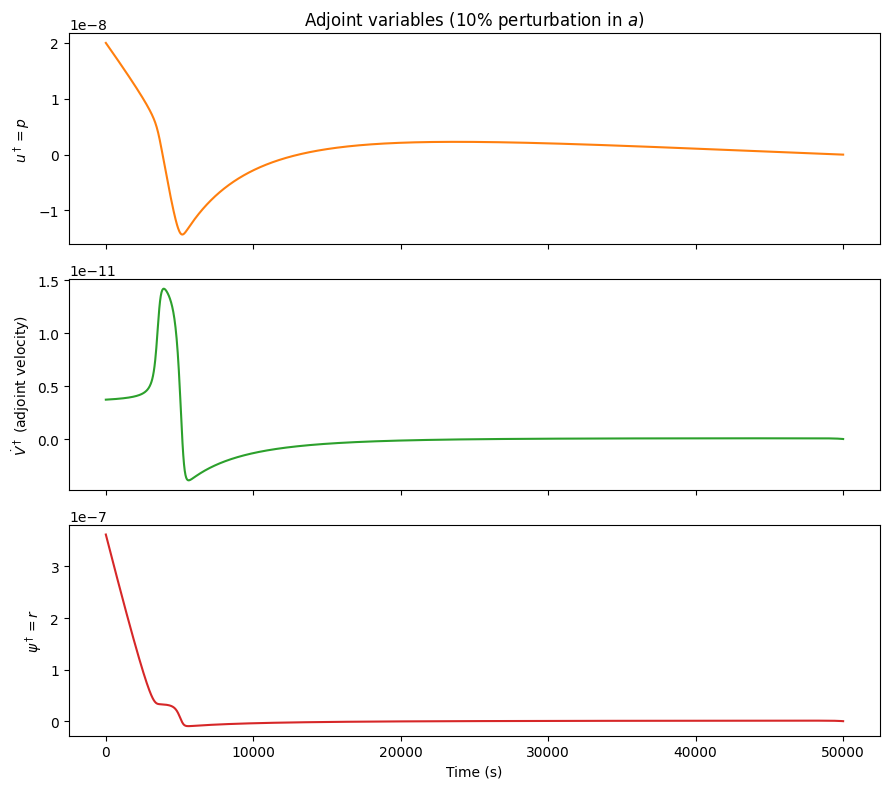

p(T) = 0.00e+00  (should be 0)
r(T) = 0.00e+00  (should be 0)


In [68]:
# ------------------------------------------------------------------
# Plot 2: Adjoint variables
# ------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

axes[0].plot(fwd_test['t'], adj_test['p'], color='C1')
axes[0].set_ylabel(r'$u^\dagger = p$')
axes[0].set_title('Adjoint variables (10% perturbation in $a$)')

axes[1].plot(fwd_test['t'], adj_test['Vdt'], color='C2')
axes[1].set_ylabel(r'$\dot{V}^\dagger$ (adjoint velocity)')

axes[2].plot(fwd_test['t'], adj_test['r'], color='C3')
axes[2].set_ylabel(r'$\psi^\dagger = r$')
axes[2].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

# Sanity check: adjoint terminal conditions
print(f"p(T) = {adj_test['p'][-1]:.2e}  (should be 0)")
print(f"r(T) = {adj_test['r'][-1]:.2e}  (should be 0)")

## Gradient Validation: Finite Differences

Compare the adjoint gradient $dJ/da$ against central finite differences:
$$\left.\frac{dJ}{da}\right|_{\rm FD} \approx \frac{J(a+h) - J(a-h)}{2h}$$

The adjoint gradient and FD gradient should agree to high relative accuracy for well-chosen $h$.

In [69]:
def J_at_a(a_val, M_base, T, nt, u0, psi0, V_obs_arr):
    """Forward solve + compute J for a given a."""
    Mc = dict(M_base)
    Mc['a'] = a_val
    fwd_ = forward_solve(Mc, T, nt, u0, psi0)
    return compute_J(fwd_, V_obs_arr)

# Adjoint gradient at the perturbed point
a0       = M_test['a']
grad_adj_val = grad_adj

print(f"a0 = {a0:.6f}")
print(f"Adjoint gradient dJ/da = {grad_adj_val:.8e}")
print()
print(f"{'h/a':>12s}  {'h':>12s}  {'dJ/da (adj)':>16s}  {'dJ/da (FD)':>16s}  {'rel error':>12s}")
print('-'*76)

h_fracs = [1e-2, 3e-3, 1e-3, 3e-4, 1e-4, 3e-5, 1e-5]
fd_grads = []
rel_errs = []

for hf in h_fracs:
    h  = hf * a0
    Jp = J_at_a(a0 + h, M_test, T, nt, u_init, psi_init, V_obs)
    Jm = J_at_a(a0 - h, M_test, T, nt, u_init, psi_init, V_obs)
    gfd = (Jp - Jm) / (2.0 * h)
    rel = abs(gfd - grad_adj_val) / abs(grad_adj_val)
    fd_grads.append(gfd)
    rel_errs.append(rel)
    print(f"{hf:>12.1e}  {h:>12.4e}  {grad_adj_val:>16.8e}  {gfd:>16.8e}  {rel:>12.2e}")

a0 = 0.016500
Adjoint gradient dJ/da = 1.56174139e-06

         h/a             h       dJ/da (adj)        dJ/da (FD)     rel error
----------------------------------------------------------------------------
     1.0e-02    1.6500e-04    1.56174139e-06    1.57341185e-06      7.47e-03
     3.0e-03    4.9500e-05    1.56174139e-06    1.56921274e-06      4.78e-03
     1.0e-03    1.6500e-05    1.56174139e-06    1.56884380e-06      4.55e-03
     3.0e-04    4.9500e-06    1.56174139e-06    1.56880184e-06      4.52e-03
     1.0e-04    1.6500e-06    1.56174139e-06    1.56879815e-06      4.52e-03
     3.0e-05    4.9500e-07    1.56174139e-06    1.56879773e-06      4.52e-03
     1.0e-05    1.6500e-07    1.56174139e-06    1.56879768e-06      4.52e-03


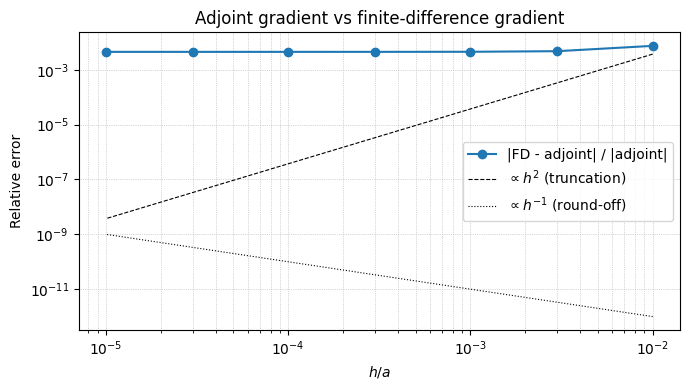

In [72]:
# ------------------------------------------------------------------
# Plot 3: FD convergence
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(h_fracs, rel_errs, 'o-', label='|FD - adjoint| / |adjoint|')
# Reference slopes
hf_arr = np.array(h_fracs)
ax.loglog(hf_arr, 0.5*hf_arr**2 / hf_arr[0]**2 * rel_errs[0], 'k--', lw=0.8, label=r'$\propto h^2$ (truncation)')
ax.loglog(hf_arr, 1e-14 / hf_arr, 'k:', lw=0.8, label=r'$\propto h^{-1}$ (round-off)')
ax.set_xlabel('$h/a$')
ax.set_ylabel('Relative error')
ax.set_title('Adjoint gradient vs finite-difference gradient')
ax.legend()
ax.grid(True, which='both', ls=':', lw=0.5)
plt.tight_layout()
plt.show()

## Simple Gradient Descent: Recover True $a$

Start at $a = 1.1\,a_{\rm true}$, take gradient steps $a \leftarrow a - \alpha\,dJ/da$.

The step size is kept fixed (chosen so early steps don't overshoot).

In [77]:
a_true_val = M_true['a']       # 0.015
a_curr     = 0.008  # start 10% high

# Initial step size (used only for iteration 1; BB takes over after that)
alpha_init = abs(a_curr) / abs(grad_adj) * 0.01

n_iter    = 15   # BB converges much faster; fewer iterations needed
J_hist    = []
a_hist    = [a_curr]
grad_hist = []
V_hist    = []

a_prev    = None
grad_prev = None

for it in range(n_iter):
    Mc = dict(M_true)
    Mc['a'] = a_curr

    fwd_it  = forward_solve(Mc, T, nt, u_init, psi_init)
    J_it    = compute_J(fwd_it, V_obs)
    adj_it  = adjoint_solve(fwd_it, V_obs, Mc)
    grad_it = compute_grad_a(fwd_it, adj_it, Mc)

    J_hist.append(J_it)
    grad_hist.append(grad_it)
    V_hist.append(fwd_it['V'].copy())

    # Barzilai-Borwein step size: α = |Δa / Δg|  (secant approx of inv-Hessian)
    if a_prev is None or abs(grad_it - grad_prev) < 1e-30:
        alpha = alpha_init
    else:
        alpha = abs((a_curr - a_prev) / (grad_it - grad_prev))

    a_prev    = a_curr
    grad_prev = grad_it

    a_curr = a_curr - alpha * grad_it
    a_hist.append(a_curr)

    print(f"iter {it+1:3d}: J = {J_it:.4e},  a = {a_curr:.6f},  "
          f"a_err = {abs(a_curr - a_true_val)/a_true_val*100:.3f}%,  "
          f"α = {alpha:.3e},  dJ/da = {grad_it:.4e}")

iter   1: J = 3.0690e-08,  a = 0.008001,  a_err = 46.662%,  α = 5.122e+01,  dJ/da = -1.4944e-08
iter   2: J = 3.0690e-08,  a = 0.009211,  a_err = 38.592%,  α = 8.095e+04,  dJ/da = -1.4953e-08
iter   3: J = 3.0658e-08,  a = 0.011071,  a_err = 26.192%,  α = 4.344e+04,  dJ/da = -4.2820e-08
iter   4: J = 3.0200e-07,  a = 0.012931,  a_err = 13.793%,  α = 1.371e-01,  dJ/da = -1.3568e-02
iter   5: J = 2.3987e-08,  a = 0.012934,  a_err = 13.771%,  α = 1.373e-01,  dJ/da = -2.3528e-05
iter   6: J = 2.3911e-08,  a = 0.014087,  a_err = 6.090%,  α = 4.911e+01,  dJ/da = -2.3462e-05
iter   7: J = 5.8974e-09,  a = 0.014980,  a_err = 0.136%,  α = 8.718e+01,  dJ/da = -1.0245e-05
iter   8: J = 4.1667e-12,  a = 0.015017,  a_err = 0.113%,  α = 9.081e+01,  dJ/da = -4.1010e-07
iter   9: J = 2.8061e-12,  a = 0.015000,  a_err = 0.002%,  α = 5.047e+01,  dJ/da = 3.2778e-07
iter  10: J = 1.3255e-15,  a = 0.015000,  a_err = 0.000%,  α = 5.161e+01,  dJ/da = 7.2173e-09
iter  11: J = 5.2803e-19,  a = 0.015000,  a_err

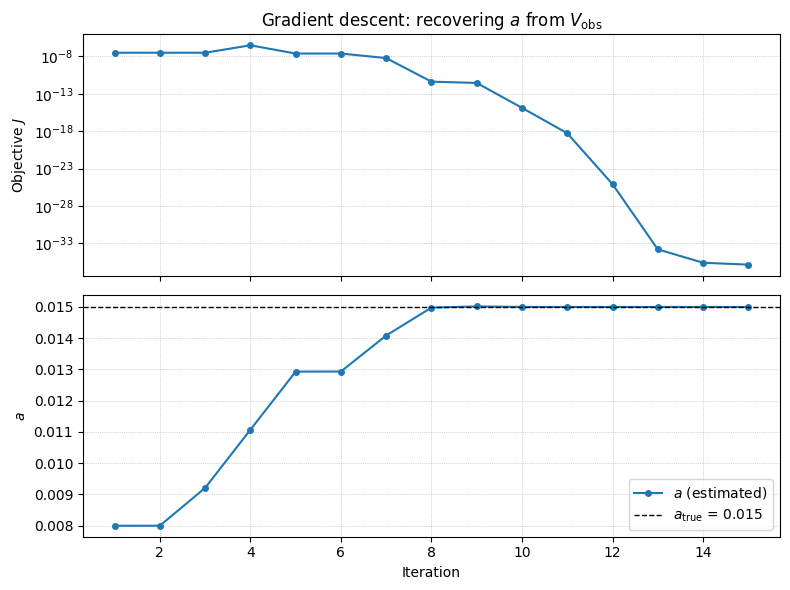


Final a = 0.015000  (true a = 0.015000,  error = 0.0000%)


In [78]:
# ------------------------------------------------------------------
# Plot 4: Gradient descent convergence
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

iters = np.arange(1, n_iter + 1)

axes[0].semilogy(iters, J_hist, 'o-', ms=4)
axes[0].set_ylabel('Objective $J$')
axes[0].set_title('Gradient descent: recovering $a$ from $V_{\\rm obs}$')
axes[0].grid(True, ls=':', lw=0.5)

axes[1].plot(iters, a_hist[:-1], 'o-', ms=4, label='$a$ (estimated)')
axes[1].axhline(a_true_val, color='k', ls='--', lw=1.0, label=f'$a_{{\\rm true}}$ = {a_true_val}')
axes[1].set_ylabel('$a$')
axes[1].set_xlabel('Iteration')
axes[1].legend()
axes[1].grid(True, ls=':', lw=0.5)

plt.tight_layout()
plt.show()

print(f"\nFinal a = {a_hist[-1]:.6f}  (true a = {a_true_val:.6f},  "
      f"error = {abs(a_hist[-1]-a_true_val)/a_true_val*100:.4f}%)")

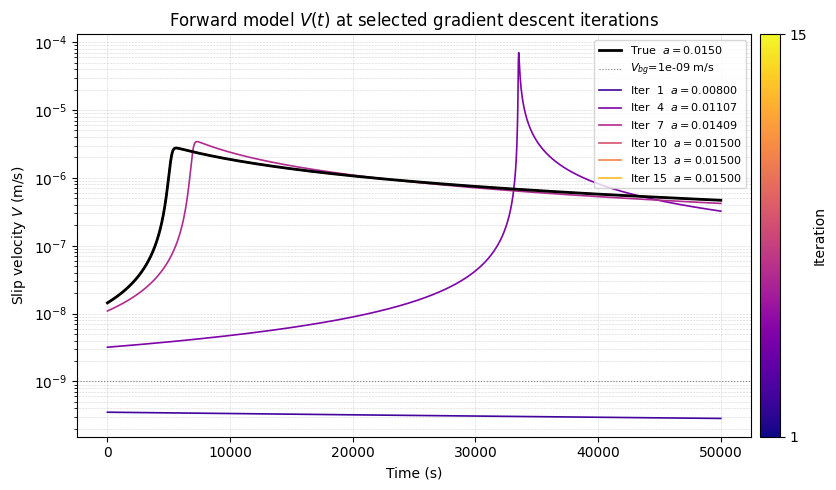

In [89]:
# ------------------------------------------------------------------
# Plot 5: Forward model V(t) — custom a value OR gradient descent overlay
# ------------------------------------------------------------------
# ---- Mode 1: single custom a value ------------------------------
# Set to a float to run a fresh forward solve and plot just that.
# Set to None to use Mode 2 (gradient descent overlay) instead.
custom_a = None          # e.g. 0.012 or 0.020
# ---- Mode 2: gradient descent overlay ---------------------------
# Use 1-based iteration numbers (1 = first GD step, n_iter = last).
# Set to None to auto-select ~6 iterations spread across all iters.
iters_to_plot = [1, 4, 7, 10, 13, 15]     # e.g. [1, 3, 7, 15, 25]
# -----------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5))

# True / observed solution always shown in black
ax.semilogy(fwd['t'], V_obs, 'k-', lw=2.0,
            label=f'True  $a={a_true_val:.4f}$', zorder=5)
ax.axhline(V_bg, color='gray', ls=':', lw=0.8,
           label=f'$V_{{bg}}$={V_bg:.0e} m/s')

if custom_a is not None:
    # --- Mode 1: single specified a value ------------------------
    print(f"Running forward solve for custom a = {custom_a} ...")
    Mc = dict(M_true)
    Mc['a'] = custom_a
    fwd_custom = forward_solve(Mc, T, nt, u_init, psi_init)
    J_custom   = compute_J(fwd_custom, V_obs)
    ax.semilogy(fwd['t'], fwd_custom['V'], color='C1', lw=1.8, ls='--',
                label=f'Custom  $a={custom_a:.5f}$  ($J={J_custom:.2e}$)')
    ax.set_title(f'Forward model $V(t)$: custom $a={custom_a}$ vs true $a={a_true_val}$')
    print(f"J(custom a) = {J_custom:.4e}")

else:
    # --- Mode 2: gradient descent iteration overlay --------------
    if iters_to_plot is None:
        idx_auto = np.unique(np.round(
            np.geomspace(1, n_iter, 6)).astype(int).clip(1, n_iter)) - 1
        iters_idx = sorted(set(idx_auto.tolist() + [n_iter - 1]))
    else:
        iters_idx = [i - 1 for i in iters_to_plot]   # convert to 0-based

    cmap_gd = plt.cm.plasma
    colors  = cmap_gd(np.linspace(0.1, 0.85, len(iters_idx)))

    for color, idx in zip(colors, iters_idx):
        a_label = a_hist[idx]
        ax.semilogy(fwd['t'], V_hist[idx], color=color, lw=1.2,
                    label=f'Iter {idx+1:2d}  $a={a_label:.5f}$')

    ax.set_title('Forward model $V(t)$ at selected gradient descent iterations')

    sm = plt.cm.ScalarMappable(cmap=cmap_gd,
         norm=plt.Normalize(vmin=1, vmax=n_iter))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label('Iteration')
    cbar.set_ticks([iters_idx[0] + 1, iters_idx[-1] + 1])

ax.set_xlabel('Time (s)')
ax.set_ylabel('Slip velocity $V$ (m/s)')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, ls=':', lw=0.4, which='both')
plt.tight_layout()
plt.show()